## Assignment-12 Random Forest

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
xls = pd.ExcelFile('Data\glass.xlsx')
print(xls.sheet_names)

['Description', 'glass']


In [45]:
data = pd.read_excel('glass.xlsx',sheet_name=1)
data.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [46]:
data.dtypes

RI      float64
Na      float64
Mg      float64
Al      float64
Si      float64
K       float64
Ca      float64
Ba      float64
Fe      float64
Type      int64
dtype: object

In [47]:
data.shape

(214, 10)

In [48]:
data.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [49]:
data.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [50]:
data.duplicated().sum()

np.int64(1)

In [51]:
data = data.drop_duplicates()

In [52]:
data.duplicated().sum()

np.int64(0)

<Figure size 800x600 with 0 Axes>

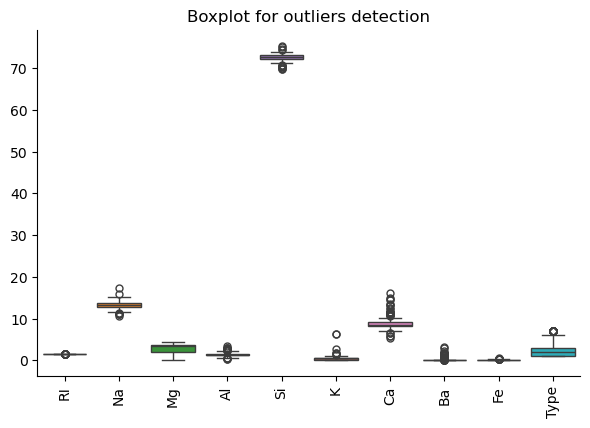

In [53]:
plt.figure(figsize=(8,6))

sns.catplot(data,
           kind='box',
           height=4,
           aspect=1.5
           )
plt.xticks(rotation=90)
plt.title('Boxplot for outliers detection')

plt.show()

In [54]:
# deleting the outliers (Optional)

cols = ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']

data1 = data.copy()

for col in cols:
    Q1 = data1[col].quantile(0.25)
    Q3 = data1[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data1 = data1[(data1[col] >= lower) & (data1[col] <= upper)]

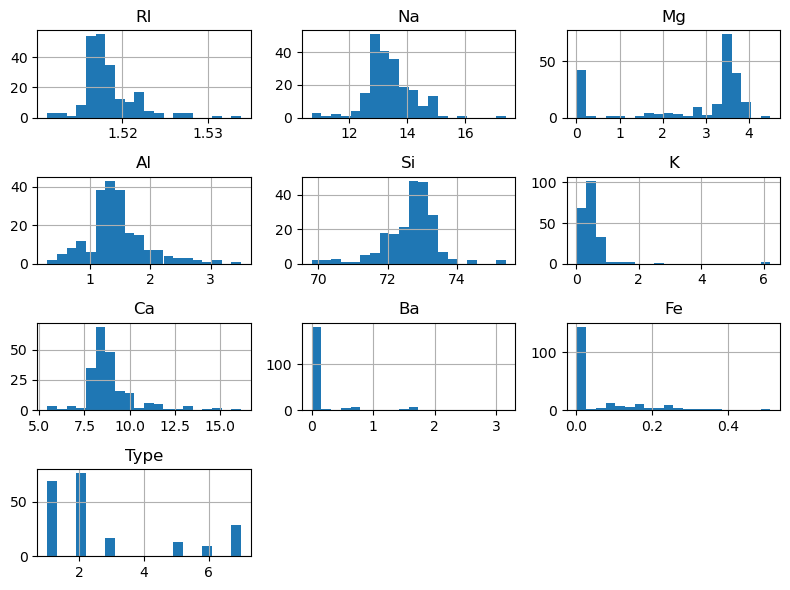

In [55]:
# histograms

data.hist(figsize=(8,6),bins=20)
plt.tight_layout()
plt.show()

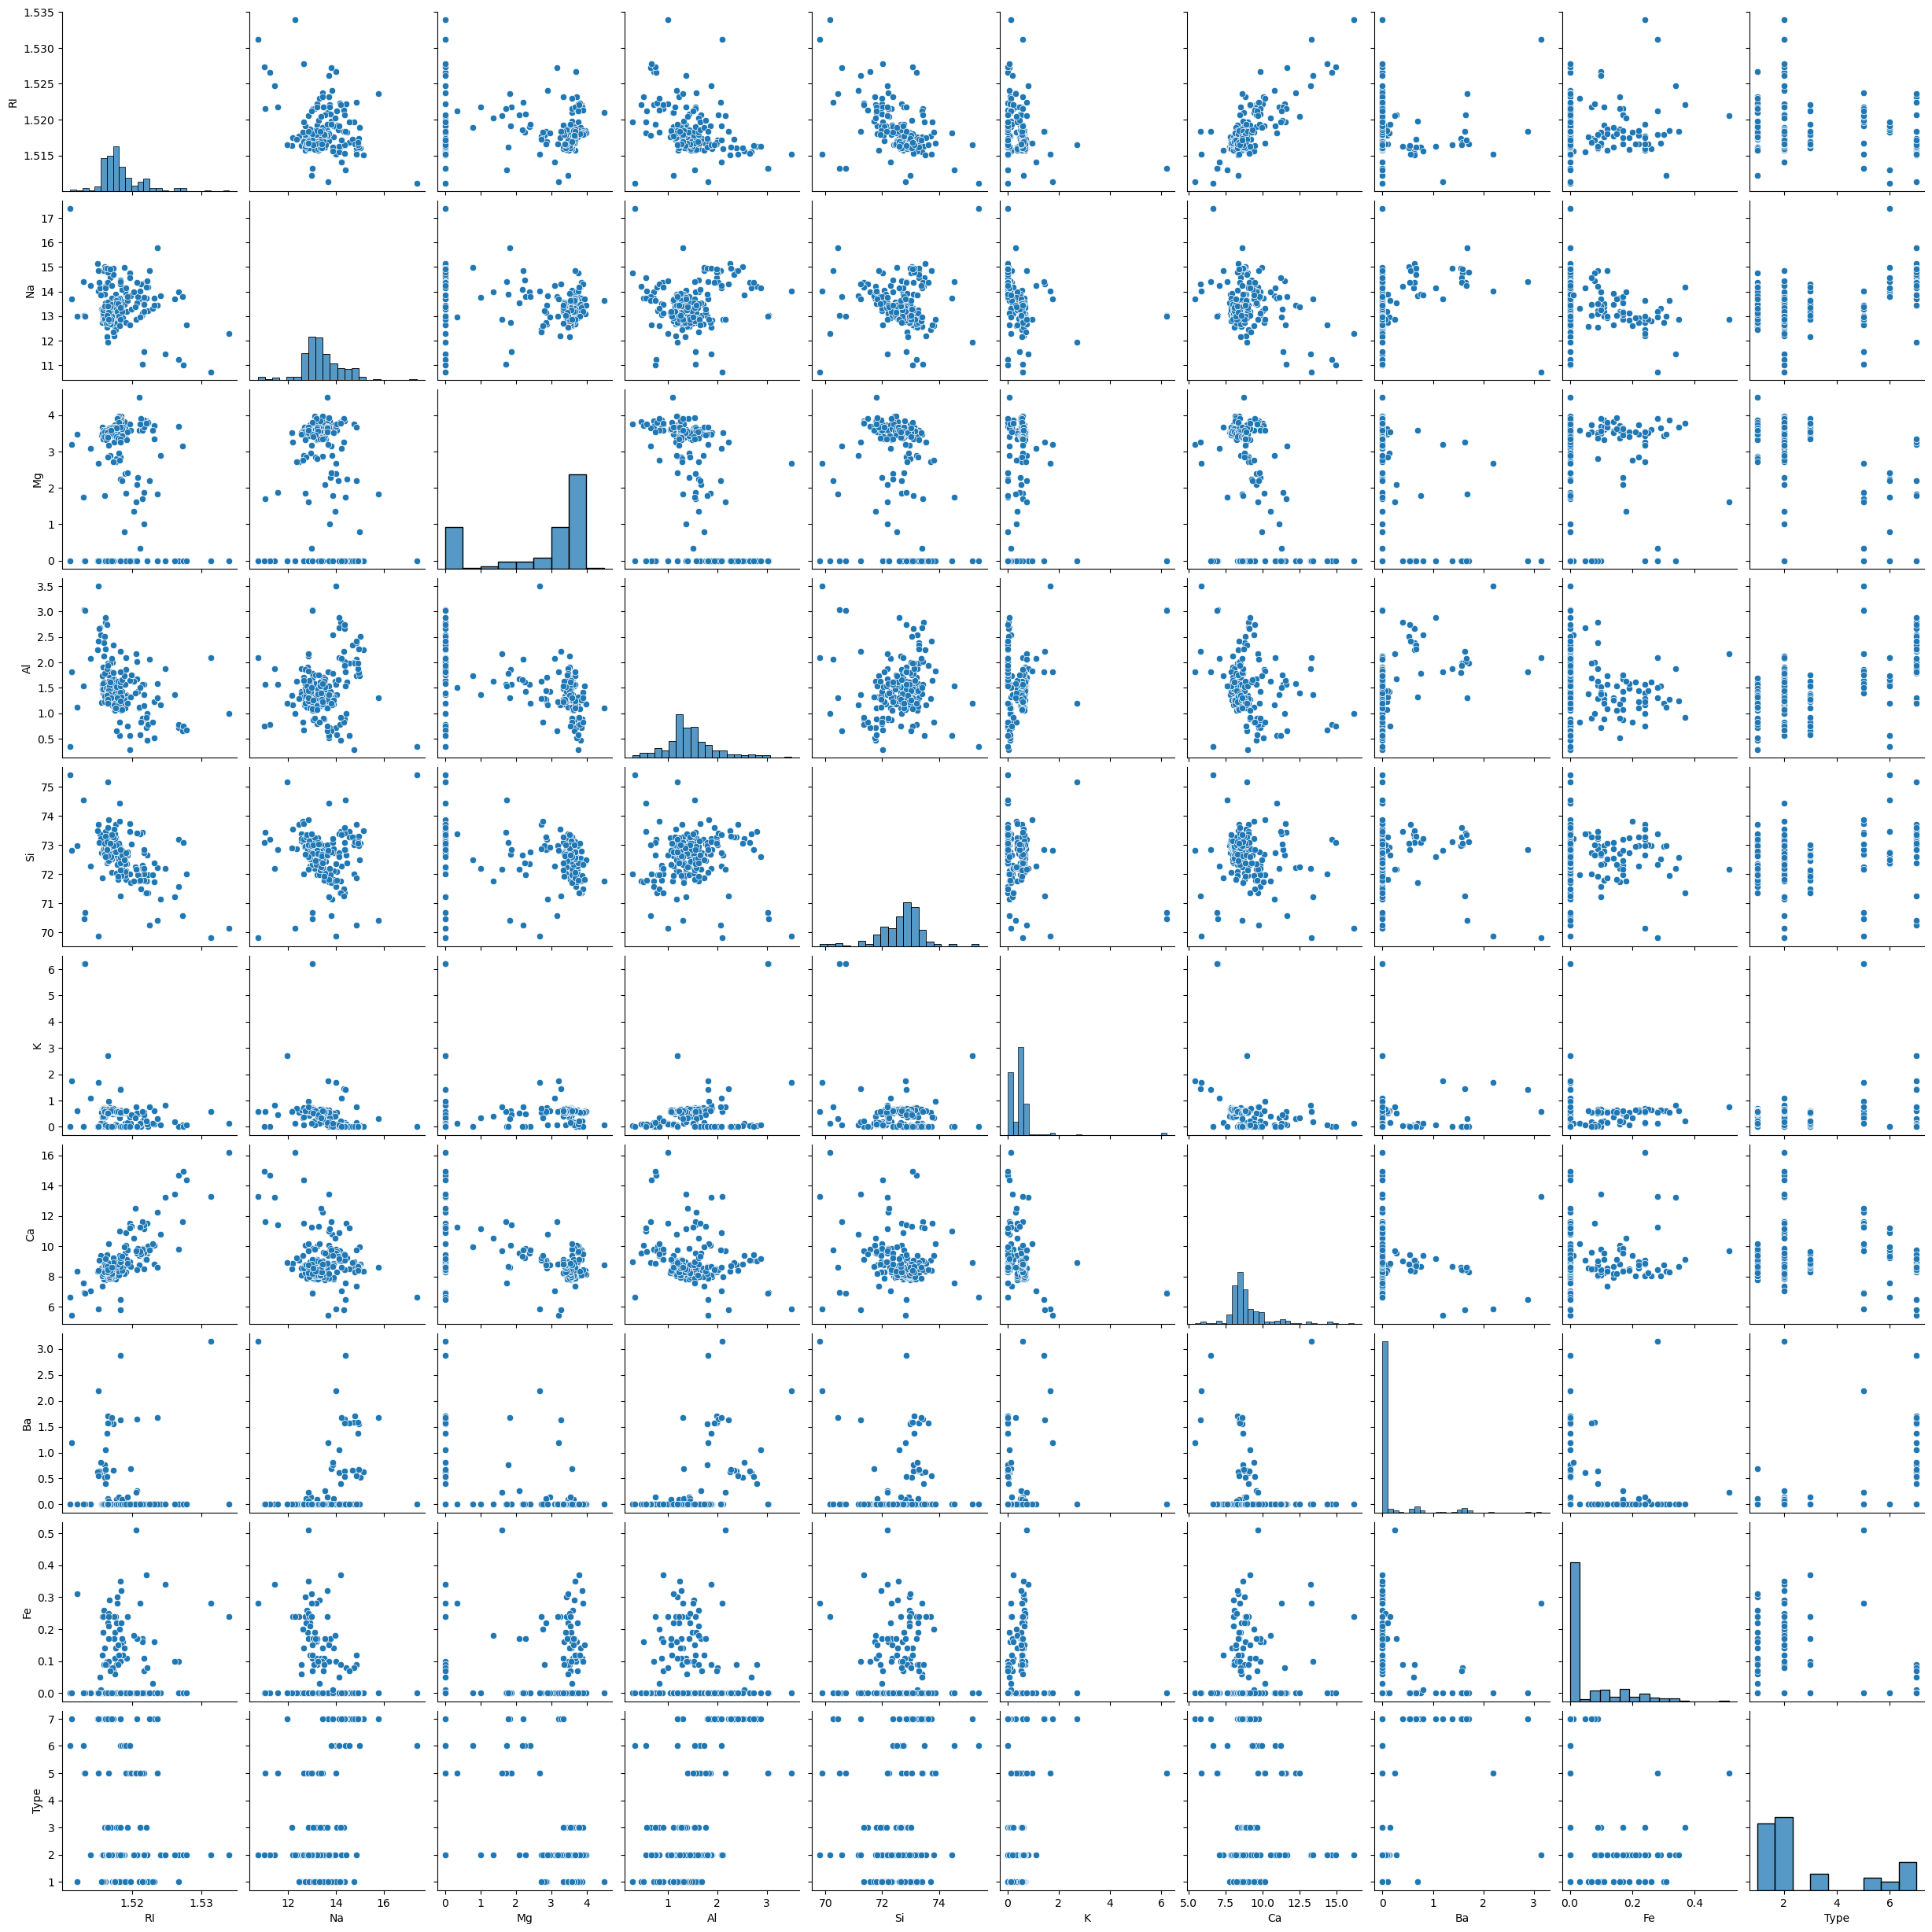

In [56]:
# Pairplots

sns.pairplot(data)
plt.show()

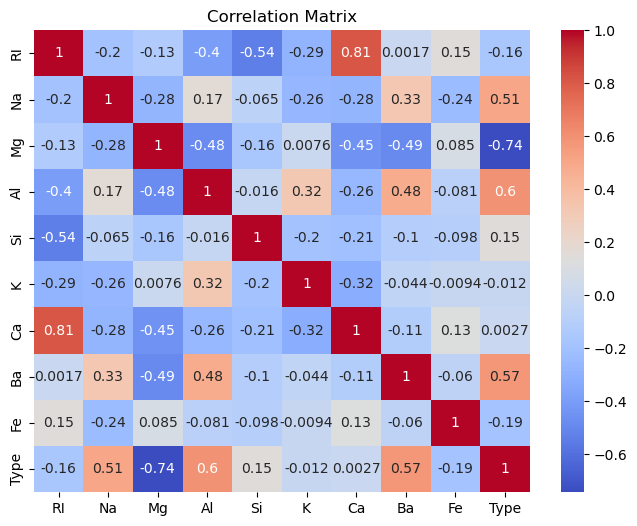

In [57]:
# Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(data.corr(),
           annot=True,
           cmap='coolwarm'
           )
plt.title('Correlation Matrix')

plt.show()

In [58]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [152]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#print(X_scaled[:5])

In [153]:
X = data.drop('Type', axis=1)
y = data['Type']

In [154]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, stratify=y, random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape 

((170, 9), (43, 9), (170,), (43,))

In [155]:
X_test.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
208,1.51640,14.37,0.00,2.74,72.85,0.00,9.45,0.54,0.0
169,1.51994,13.27,0.00,1.76,73.03,0.47,11.32,0.00,0.0
122,1.51687,13.23,3.54,1.48,72.84,0.56,8.10,0.00,0.0
172,1.51321,13.00,0.00,3.02,70.70,6.21,6.93,0.00,0.0
29,1.51784,13.08,3.49,1.28,72.86,0.60,8.49,0.00,0.0


In [156]:
# Build the model

from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier

#### Random For Model

In [157]:
rf_model = RandomForestClassifier(n_estimators=100,
    max_depth=2, 
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced'
    )
rf_model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [158]:
yhat_train = rf_model.predict(X_train)

In [161]:
print(classification_report(y_train,yhat_train))

              precision    recall  f1-score   support

           1       0.65      0.80      0.72        55
           2       0.91      0.49      0.64        61
           3       0.42      0.57      0.48        14
           5       0.53      0.90      0.67        10
           6       0.58      1.00      0.74         7
           7       0.95      0.87      0.91        23

    accuracy                           0.69       170
   macro avg       0.67      0.77      0.69       170
weighted avg       0.75      0.69      0.69       170



#### Testing Data

In [162]:
yhat_test = rf_model.predict(X_test)

In [164]:
print(classification_report(y_test,yhat_test))

              precision    recall  f1-score   support

           1       0.73      0.79      0.76        14
           2       0.83      0.33      0.48        15
           3       0.33      0.67      0.44         3
           5       0.60      1.00      0.75         3
           6       0.50      1.00      0.67         2
           7       0.86      1.00      0.92         6

    accuracy                           0.67        43
   macro avg       0.64      0.80      0.67        43
weighted avg       0.74      0.67      0.66        43



#### BaggingClassifier model

In [120]:
from sklearn.tree import DecisionTreeClassifier

In [121]:
dtree = DecisionTreeClassifier(class_weight='balanced')
bag_model = BaggingClassifier(estimator=dtree, n_estimators=200, random_state=42)

In [122]:
bag_model.fit(X_train,y_train)

,estimator,DecisionTreeC...ht='balanced')
,n_estimators,200
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,42
,verbose,0


In [174]:
from sklearn.metrics import classification_report, accuracy_score

In [176]:
#y_train.value_counts()

#### Training data

In [125]:
yhat_train = bag_model.predict(X_train)

In [127]:
print(classification_report(y_train,yhat_train))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        59
           2       1.00      1.00      1.00        61
           3       1.00      1.00      1.00        14
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         6
           7       1.00      1.00      1.00        20

    accuracy                           1.00       170
   macro avg       1.00      1.00      1.00       170
weighted avg       1.00      1.00      1.00       170



#### Testing data

In [110]:
yhat_test = bag_model.predict(X_test)

In [129]:
print(classification_report(y_test,yhat_test))

              precision    recall  f1-score   support

           1       0.60      0.90      0.72        10
           2       0.75      0.60      0.67        15
           3       1.00      0.33      0.50         3
           5       0.60      1.00      0.75         3
           6       1.00      1.00      1.00         3
           7       1.00      0.78      0.88         9

    accuracy                           0.74        43
   macro avg       0.83      0.77      0.75        43
weighted avg       0.79      0.74      0.74        43



#### Adaboost Model

In [165]:
ada_model = AdaBoostClassifier(n_estimators=100)
ada_model.fit(X_train,y_train)

,estimator,None
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


#### Training data

In [166]:
yhat_train = ada_model.predict(X_train)

In [169]:
print(classification_report(y_train,yhat_train))

              precision    recall  f1-score   support

           1       0.38      0.45      0.41        55
           2       0.40      0.44      0.42        61
           3       0.50      0.07      0.12        14
           5       0.25      0.20      0.22        10
           6       1.00      0.43      0.60         7
           7       0.92      0.96      0.94        23

    accuracy                           0.47       170
   macro avg       0.57      0.43      0.45       170
weighted avg       0.49      0.47      0.46       170



#### Testing Data

In [170]:
yhat_test = ada_model.predict(X_test)

In [173]:
print(classification_report(y_test,yhat_test))

              precision    recall  f1-score   support

           1       0.54      0.50      0.52        14
           2       0.33      0.40      0.36        15
           3       0.00      0.00      0.00         3
           5       0.14      0.33      0.20         3
           6       0.00      0.00      0.00         2
           7       0.60      0.50      0.55         6

    accuracy                           0.40        43
   macro avg       0.27      0.29      0.27        43
weighted avg       0.39      0.40      0.39        43



C:\Users\javee\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\javee\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\javee\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [ ]:
Additional Notes:
1. Explain Bagging and Boosting methods. How is it different from each other.
2. Explain how to handle imbalance in the data.Bagging vs Boosting
Bagging reduces variance using parallel models.
Boosting reduces bias using sequential learning.
Imbalanced Data Handling
Use SMOTE, undersampling, or class weighting.
Evaluate models using Recall and F1-score rather than accuracy alone.
Apply resampling only on training data to avoid data leakage.

#### Additional notes

##### 1. Explain Bagging and Boosting methods. How is it different from each other.

Bagging reduces variance using parallel models.

Boosting reduces bias using sequential learning.


##### 2. Explain how to handle imbalance in the data.Bagging vs Boosting

Use SMOTE, undersampling, or class weighting.

Evaluate models using Recall and F1-score rather than accuracy alone.

Apply resampling only on training data to avoid data leakage.